In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

In [9]:
# Load the three datasets, using the first column (patient id) as the index
datasets = {}
for name in ["metadata", "microbiome", "metabolome"]:
    df = pd.read_csv(f"train/{name}.csv")
    df = df.rename(columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")
    datasets[name] = df
    print(f"{name:11s} -> {df.shape[0]} rows (patients), {df.shape[1]} features")

metadata    -> 1738 rows (patients), 5 features
microbiome  -> 1738 rows (patients), 170 features
metabolome  -> 1738 rows (patients), 102 features


metabolome samples used: 1390 | features: 102
metabolome x metabolome MI shape: (102, 102)


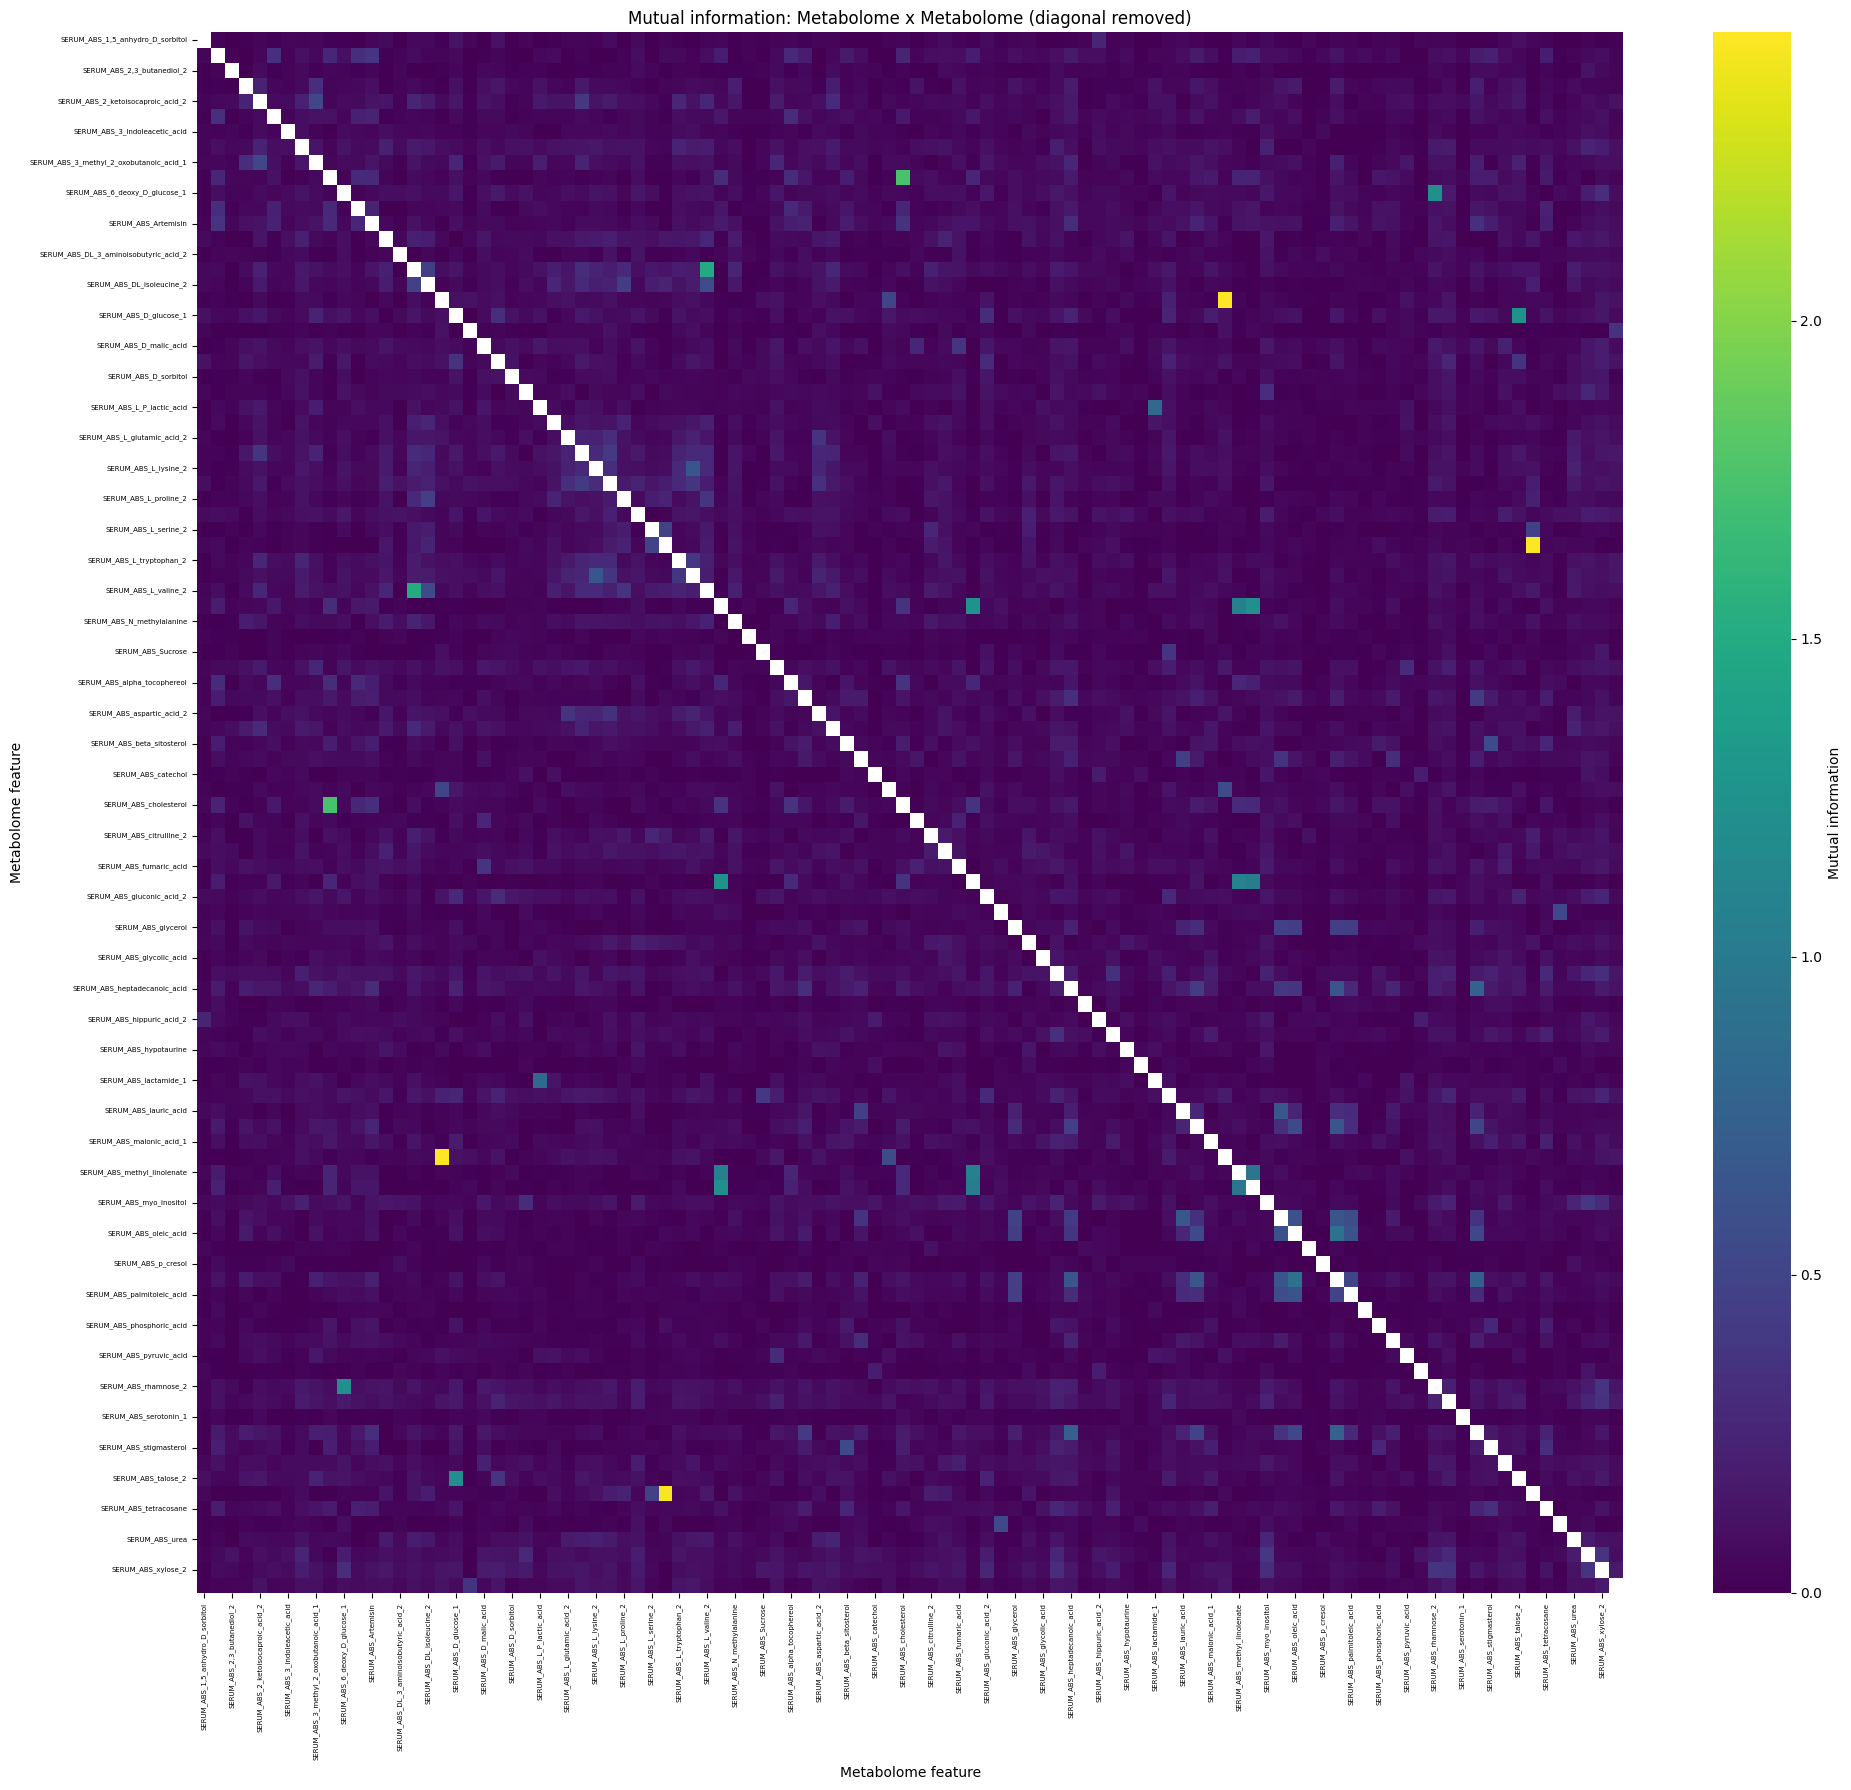

In [10]:
def mi_matrix_between(rows_df, cols_df, random_state=0):
    """MI matrix where entry [i, j] = MI(rows_df[i], cols_df[j]).

    Both inputs are standardized independently before estimation.
    """
    rows_scaled = StandardScaler().fit_transform(rows_df)
    cols_scaled = StandardScaler().fit_transform(cols_df)
    out = pd.DataFrame(index=rows_df.columns, columns=cols_df.columns, dtype=float)
    for i, name in enumerate(rows_df.columns):
        out.loc[name] = mutual_info_regression(
            cols_scaled, rows_scaled[:, i], random_state=random_state)
    return out

metab_clean = (pd.read_csv("train/metabolome.csv")
               .rename(columns={"Unnamed: 0": "SampleID"})
               .set_index("SampleID").dropna(how="all"))
print(f"metabolome samples used: {len(metab_clean)} | features: {metab_clean.shape[1]}")



# Within-dataset MI matrices (symmetric; diagonal = self-information, set to NaN)
mi_metab = mi_matrix_between(metab_clean, metab_clean)
for mat in (mi_metab,):
    for k in range(len(mat)):
        mat.iat[k, k] = np.nan

print("metabolome x metabolome MI shape:", mi_metab.shape)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(mi_metab.astype(float), cmap="viridis",
            cbar_kws={"label": "Mutual information"}, ax=ax)
ax.set_title("Mutual information: Metabolome x Metabolome (diagonal removed)")
ax.set_xlabel("Metabolome feature")
ax.set_ylabel("Metabolome feature")
plt.xticks(fontsize=5, rotation=90)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()


## 1. Metabolome trends across disease states



In [11]:
# --- 14.0 Cohort setup: France only, group 8 = control (metabolome) -----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu, false_discovery_control
from skbio.stats.distance import DistanceMatrix, permanova
from sklearn.decomposition import PCA

_meta = pd.read_csv("train/metadata.csv").rename(
    columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")
_metab = pd.read_csv("train/metabolome.csv").rename(
    columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")

# France patients with a complete metabolome row (controls the center confounder)
_france = _meta.index[_meta["CENTER_C"] == "France"]
_complete = _metab.index[_metab.notna().all(axis=1)]
mcohort_ids = _france.intersection(_complete)

# Serum metabolome is NOT compositional: raw values are used directly (no closure,
# no CLR). z-scoring is applied ONLY for distance/ordination so that all 102
# metabolites contribute on a comparable scale.
metab = _metab.loc[mcohort_ids].astype(float)
metab_log2 = np.log2(metab)                                # for visualization only
metab_z = (metab - metab.mean()) / metab.std(ddof=0)       # for ordination/distance
groups = _meta.loc[mcohort_ids, "PATGROUPFINAL_C"].astype(str)

CONTROL = "8"
DISEASE = ["1", "2a", "2b", "3", "4", "5", "6", "7"]
GROUP_ORDER = DISEASE + [CONTROL]
GROUP_LABELS = {
    "1": "Metabolic syndrome", "2a": "Severe obesity",
    "2b": "Severe obesity (bariatric)", "3": "Type 2 diabetes",
    "4": "Cardiac group 4", "5": "Cardiac group 5", "6": "Cardiac group 6",
    "7": "Cardiac group 7", "8": "Control (lean)",
}
palette = dict(zip(GROUP_ORDER, sns.color_palette("husl", len(GROUP_ORDER))))

print(f"France complete-metabolome cohort n = {len(mcohort_ids)}  "
      f"({metab.shape[1]} metabolites)")
_counts = groups.value_counts().reindex(GROUP_ORDER)
print(_counts.to_string())
print("\nNote: groups 6 (n={}) and 7 (n={}) are underpowered - "
      "interpret their contrasts with caution.".format(
          int(_counts.get("6", 0)), int(_counts.get("7", 0))))

France complete-metabolome cohort n = 589  (102 metabolites)
PATGROUPFINAL_C
1      59
2a     92
2b     24
3     227
4      35
5      56
6      17
7      12
8      67

Note: groups 6 (n=17) and 7 (n=12) are underpowered - interpret their contrasts with caution.


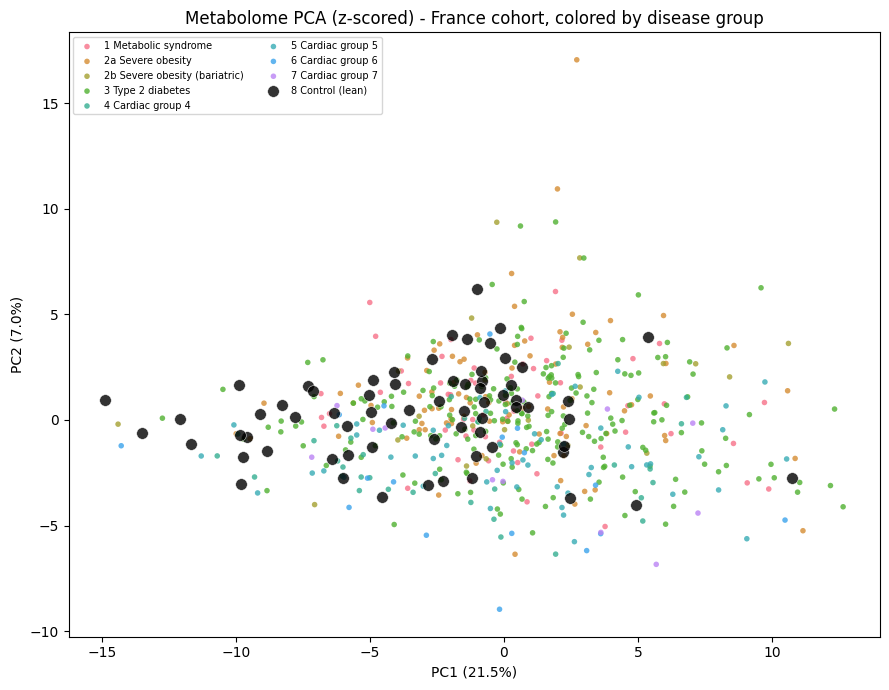

GLOBAL PERMANOVA (all 9 groups, Euclidean on z-scores): pseudo-F=4.69  R2=0.061  p=0.001

Pairwise PERMANOVA vs control:


,group,label,n,pseudo_F,R2,p,fdr
0,1,Metabolic syndrome,59,8.64,0.065,0.001,0.001333
1,2a,Severe obesity,92,9.86,0.059,0.001,0.001333
2,2b,Severe obesity (bariatric),24,6.58,0.069,0.001,0.001333
3,3,Type 2 diabetes,227,18.43,0.059,0.001,0.001333
4,4,Cardiac group 4,35,5.64,0.053,0.001,0.001333
5,5,Cardiac group 5,56,8.78,0.068,0.001,0.001333
6,6,Cardiac group 6,17,4.50,0.052,0.002,0.002000
7,7,Cardiac group 7,12,4.39,0.054,0.002,0.002000


In [12]:
# --- 14.1 Overall structure: does the metabolome separate disease states? -----
def _permanova_r2(F, n, a):
    """Recover R^2 from the pseudo-F statistic and the design degrees of freedom."""
    return (F * (a - 1)) / (F * (a - 1) + (n - a))


def run_permanova(dm, grouping, perms=999):
    r = permanova(dm, grouping, permutations=perms)
    F = r["test statistic"]
    return F, _permanova_r2(F, int(r["sample size"]), int(r["number of groups"])), r["p-value"]


# Euclidean distance on z-scored metabolites (comparable scale across metabolites)
sample_ids = list(metab_z.index.astype(str))
dm_euc = DistanceMatrix(squareform(pdist(metab_z.to_numpy(), metric="euclidean")),
                        sample_ids)
g_arr = groups.to_numpy()

# PCA ordination
pca = PCA(n_components=2, random_state=0).fit(metab_z.to_numpy())
coords = pca.transform(metab_z.to_numpy())
ve = pca.explained_variance_ratio_[:2] * 100

fig, ax = plt.subplots(figsize=(9, 7))
for g in GROUP_ORDER:
    m = g_arr == g
    is_ctrl = g == CONTROL
    ax.scatter(coords[m, 0], coords[m, 1],
               s=70 if is_ctrl else 16, alpha=0.8,
               color="black" if is_ctrl else palette[g],
               edgecolor="white" if is_ctrl else "none", linewidth=0.4,
               label=f"{g} {GROUP_LABELS[g]}")
ax.set_xlabel(f"PC1 ({ve[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({ve[1]:.1f}%)")
ax.set_title("Metabolome PCA (z-scored) - France cohort, colored by disease group")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

# Global PERMANOVA across all 9 groups
F, r2, p = run_permanova(dm_euc, g_arr)
print(f"GLOBAL PERMANOVA (all 9 groups, Euclidean on z-scores): "
      f"pseudo-F={F:.2f}  R2={r2:.3f}  p={p:.3f}")

# Pairwise: each disease group vs control (BH across the 8 contrasts)
rows, ps = [], []
for g in DISEASE:
    sel = np.isin(g_arr, [g, CONTROL])
    sub_dm = dm_euc.filter([i for i, s in zip(sample_ids, sel) if s])
    F, r2, p = run_permanova(sub_dm, groups[sel].to_numpy())
    rows.append(dict(group=g, label=GROUP_LABELS[g], n=int((g_arr == g).sum()),
                     pseudo_F=round(F, 2), R2=round(r2, 3), p=p)); ps.append(p)
permanova_pw = pd.DataFrame(rows)
permanova_pw["fdr"] = false_discovery_control(ps)
print("\nPairwise PERMANOVA vs control:")
permanova_pw

In [13]:
# --- 14.2 Per-metabolite differential abundance vs control --------------------
# Mann-Whitney U on RAW values (scale-free), log2 fold-change from group medians,
# rank-biserial effect size (+ = elevated in disease), Benjamini-Hochberg FDR.
def metab_diff(group):
    """Differential abundance of every metabolite: disease `group` vs control."""
    d_idx = (groups == group).to_numpy()
    c_idx = (groups == CONTROL).to_numpy()
    n1, n2 = int(d_idx.sum()), int(c_idx.sum())
    recs = []
    for met in metab.columns:
        a = metab.loc[d_idx, met].to_numpy()
        b = metab.loc[c_idx, met].to_numpy()
        U, p = mannwhitneyu(a, b, alternative="two-sided")
        rbc = 2 * U / (n1 * n2) - 1               # rank-biserial; + means disease > control
        med_d, med_c = np.median(a), np.median(b)
        recs.append((met, np.log2(med_d / med_c), med_d - med_c, rbc, p))
    df = pd.DataFrame(recs, columns=["metabolite", "log2fc", "median_diff",
                                     "rank_biserial", "p"]).set_index("metabolite")
    df["fdr"] = false_discovery_control(df["p"].to_numpy())
    return df.sort_values("fdr")


da_metab = {g: metab_diff(g) for g in DISEASE}

sig_counts = pd.DataFrame({
    "n": [int((groups == g).sum()) for g in DISEASE],
    "n_sig": [int((da_metab[g]["fdr"] < 0.05).sum()) for g in DISEASE],
    "n_up": [int(((da_metab[g]["fdr"] < 0.05) & (da_metab[g]["log2fc"] > 0)).sum())
             for g in DISEASE],
    "n_down": [int(((da_metab[g]["fdr"] < 0.05) & (da_metab[g]["log2fc"] < 0)).sum())
               for g in DISEASE],
}, index=DISEASE)
sig_counts.index.name = "group"
sig_counts["label"] = [GROUP_LABELS[g] for g in DISEASE]
print("Significant metabolites (FDR < 0.05) per disease group vs control "
      f"(out of {metab.shape[1]}):")
sig_counts

Significant metabolites (FDR < 0.05) per disease group vs control (out of 102):


,n,n_sig,n_up,n_down,label
group,,,,,
1,59,55,50,5,Metabolic syndrome
2a,92,62,57,5,Severe obesity
2b,24,48,43,5,Severe obesity (bariatric)
3,227,70,60,10,Type 2 diabetes
4,35,42,30,12,Cardiac group 4
5,56,74,64,10,Cardiac group 5
6,17,24,17,7,Cardiac group 6
7,12,18,17,1,Cardiac group 7


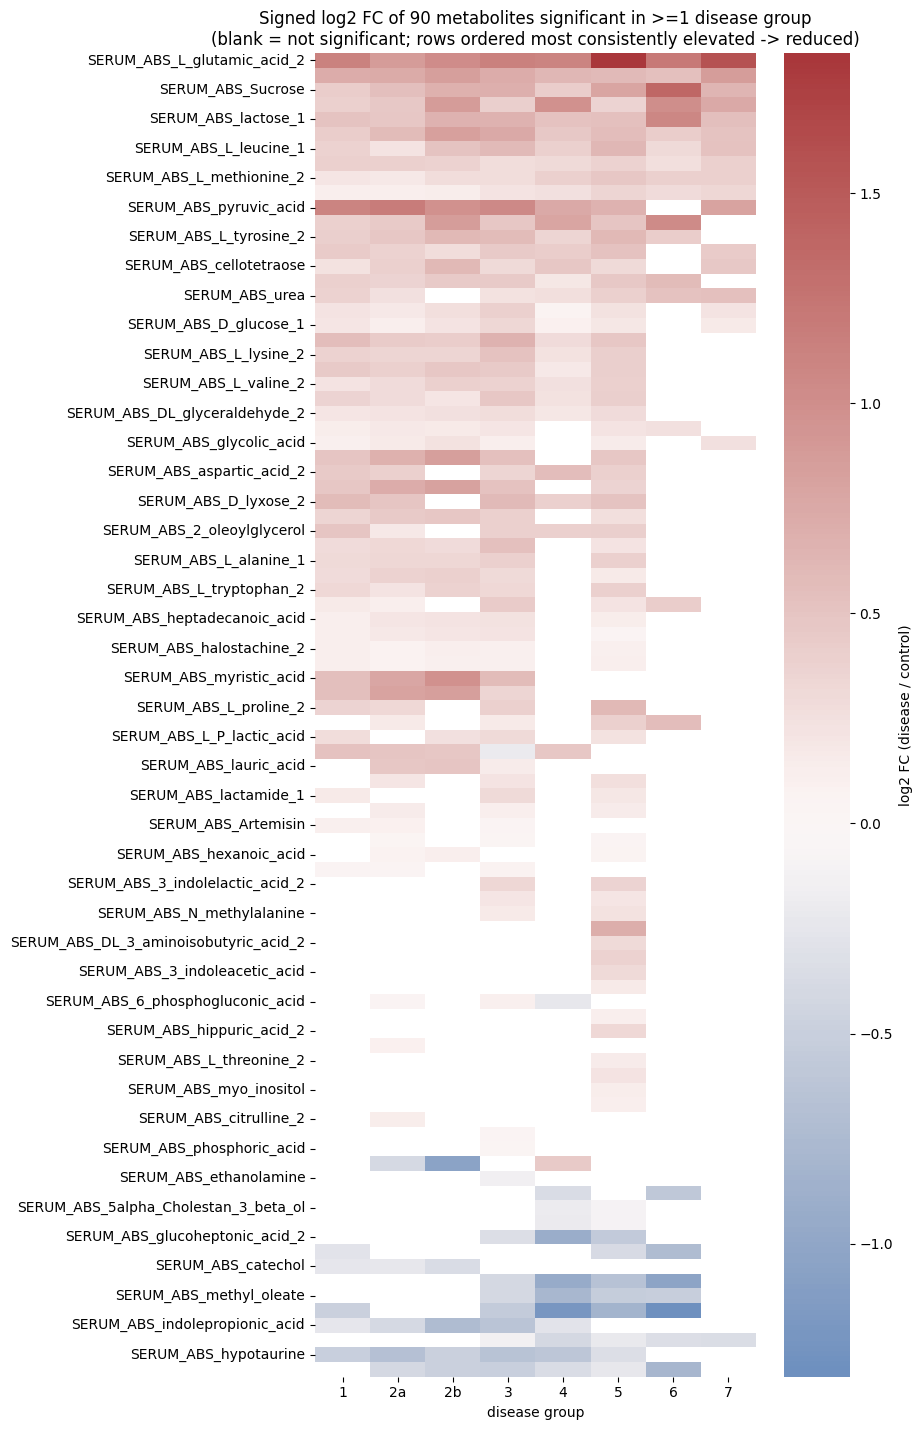

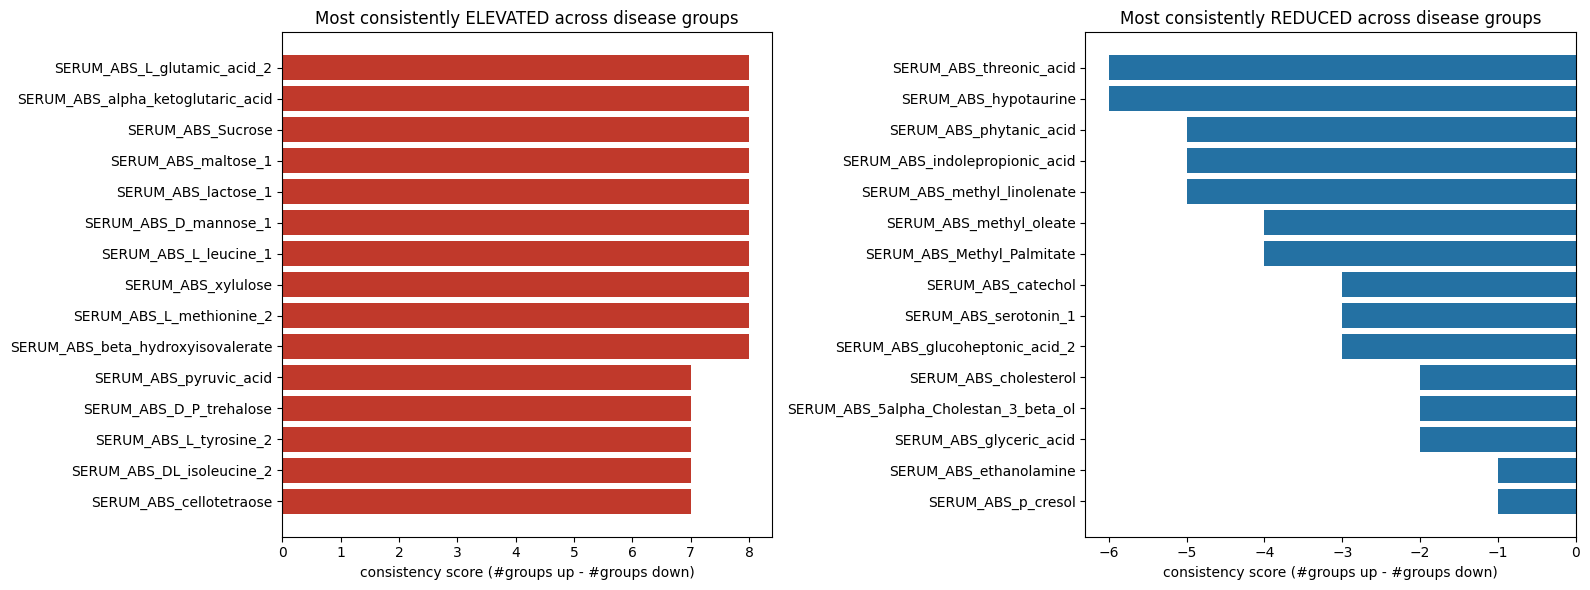

Top consistently ELEVATED metabolites:
                                   n_up  n_down  score  mean_abs_log2fc
SERUM_ABS_L_glutamic_acid_2           8       0      8         1.238450
SERUM_ABS_alpha_ketoglutaric_acid     8       0      8         0.705434
SERUM_ABS_Sucrose                     8       0      8         0.696230
SERUM_ABS_maltose_1                   8       0      8         0.657159
SERUM_ABS_lactose_1                   8       0      8         0.624662
SERUM_ABS_D_mannose_1                 8       0      8         0.568814
SERUM_ABS_L_leucine_1                 8       0      8         0.444302
SERUM_ABS_xylulose                    8       0      8         0.348229
SERUM_ABS_L_methionine_2              8       0      8         0.327079
SERUM_ABS_beta_hydroxyisovalerate     8       0      8         0.225630
SERUM_ABS_pyruvic_acid                7       0      7         0.827208
SERUM_ABS_D_P_trehalose               7       0      7         0.628590
SERUM_ABS_L_tyrosine_2   

In [14]:
# --- 14.3 Consistency: which metabolites move the same way across diseases? ----
# Signed log2FC matrix (metabolite x disease group), non-significant cells masked.
log2fc_mat = pd.DataFrame(
    {g: da_metab[g]["log2fc"].where(da_metab[g]["fdr"] < 0.05)
     for g in DISEASE}).reindex(metab.columns)

# Consistency score = (#groups where elevated) - (#groups where reduced), FDR<0.05.
consistency = pd.DataFrame({
    "n_up": (log2fc_mat > 0).sum(axis=1),
    "n_down": (log2fc_mat < 0).sum(axis=1),
})
consistency["score"] = consistency["n_up"] - consistency["n_down"]
consistency["mean_abs_log2fc"] = pd.DataFrame(
    {g: da_metab[g]["log2fc"] for g in DISEASE}).reindex(metab.columns).abs().mean(axis=1)
consistency = consistency.sort_values(["score", "mean_abs_log2fc"],
                                      ascending=[False, False])

# Plot A: heatmap of signed log2FC for metabolites significant in >=1 disease group
hm = log2fc_mat.loc[log2fc_mat.notna().any(axis=1)]
hm = hm.reindex(consistency.index.intersection(hm.index))   # rows ordered by consistency
fig, ax = plt.subplots(figsize=(9, max(5, len(hm) * 0.16)))
sns.heatmap(hm, cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "log2 FC (disease / control)"})
ax.set_title(f"Signed log2 FC of {len(hm)} metabolites significant in >=1 disease group\n"
             "(blank = not significant; rows ordered most consistently elevated -> reduced)")
ax.set_xlabel("disease group"); fig.tight_layout(); plt.show()

# Plot B: top consistently elevated / reduced metabolites
TOPK = 15
elevated = consistency[consistency["score"] > 0].head(TOPK).iloc[::-1]
reduced = consistency[consistency["score"] < 0].tail(TOPK)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(elevated.index, elevated["score"], color="#c0392b")
axes[0].set_title("Most consistently ELEVATED across disease groups")
axes[0].set_xlabel("consistency score (#groups up - #groups down)")
axes[1].barh(reduced.index, reduced["score"], color="#2471a3")
axes[1].set_title("Most consistently REDUCED across disease groups")
axes[1].set_xlabel("consistency score (#groups up - #groups down)")
fig.tight_layout(); plt.show()

print("Top consistently ELEVATED metabolites:")
print(consistency[consistency["score"] > 0].head(TOPK).to_string())
print("\nTop consistently REDUCED metabolites:")
print(consistency[consistency["score"] < 0].tail(TOPK).iloc[::-1].to_string())

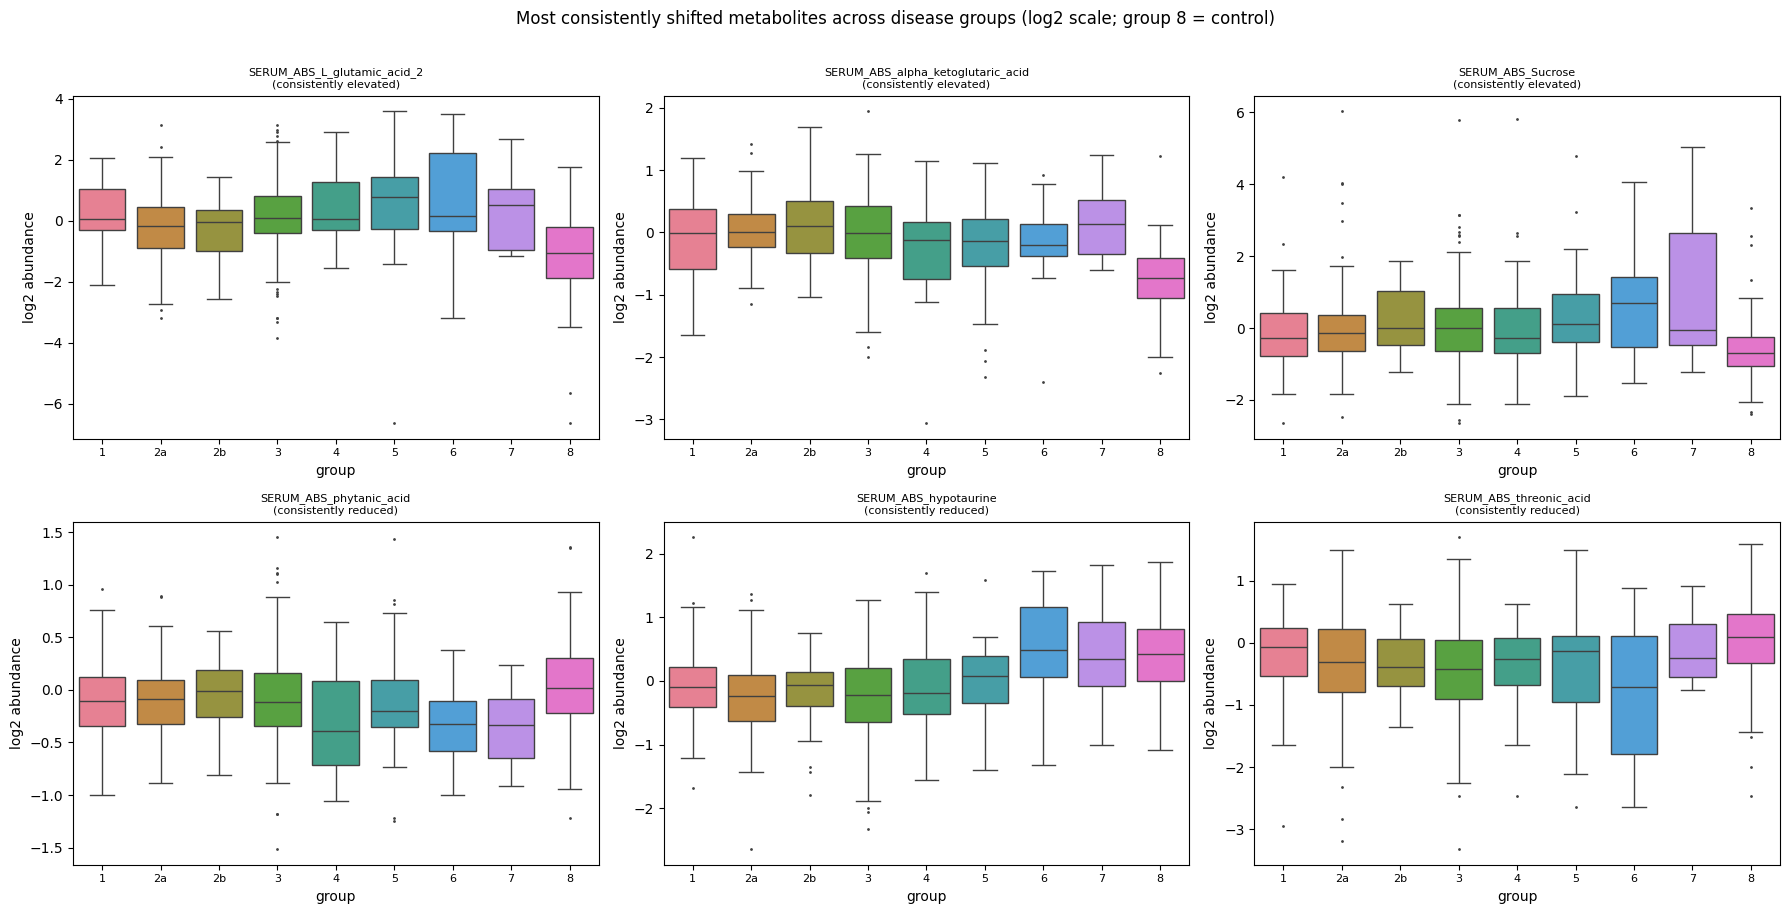

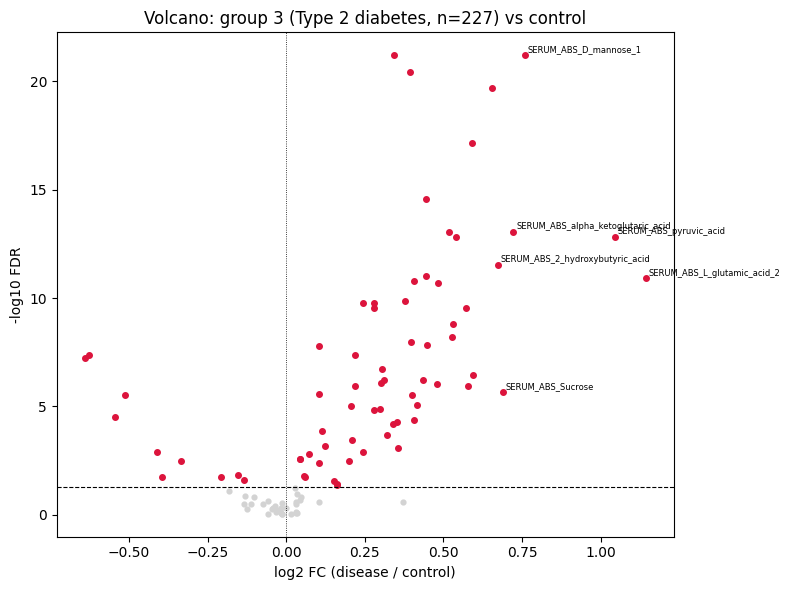

In [15]:
# --- 14.4 Detail: top consistent metabolites + T2D volcano --------------------
# (a) Boxplots (log2 scale) of the most consistently shifted metabolites
top_up = consistency[consistency["score"] > 0].head(3).index.tolist()
top_down = consistency[consistency["score"] < 0].tail(3).index.tolist()
focus = top_up + top_down
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, met in zip(axes.ravel(), focus):
    data = pd.DataFrame({"log2 abundance": metab_log2[met].to_numpy(), "group": g_arr})
    sns.boxplot(data=data, x="group", y="log2 abundance", order=GROUP_ORDER,
                hue="group", hue_order=GROUP_ORDER, palette=palette,
                legend=False, ax=ax, fliersize=1)
    direction = "elevated" if met in top_up else "reduced"
    ax.set_title(f"{met}\n(consistently {direction})", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Most consistently shifted metabolites across disease groups "
             "(log2 scale; group 8 = control)", y=1.01)
fig.tight_layout(); plt.show()

# (b) Volcano plot for the best-powered contrast: group 3 (Type 2 diabetes)
g = "3"
d = da_metab[g]
sig = d["fdr"] < 0.05
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(d.loc[~sig, "log2fc"], -np.log10(d.loc[~sig, "fdr"]), s=12, color="lightgrey")
ax.scatter(d.loc[sig, "log2fc"], -np.log10(d.loc[sig, "fdr"]), s=16, color="crimson")
ax.axhline(-np.log10(0.05), ls="--", lw=0.8, color="k")
ax.axvline(0, ls=":", lw=0.6, color="k")
# annotate the strongest hits by |log2FC|
strongest = d[sig].reindex(d[sig]["log2fc"].abs().sort_values(ascending=False).index).head(6)
for met, row in strongest.iterrows():
    ax.annotate(met, (row["log2fc"], -np.log10(row["fdr"])),
                fontsize=6, xytext=(2, 2), textcoords="offset points")
ax.set_xlabel("log2 FC (disease / control)"); ax.set_ylabel("-log10 FDR")
ax.set_title(f"Volcano: group {g} ({GROUP_LABELS[g]}, n={int((groups == g).sum())}) vs control")
fig.tight_layout(); plt.show()

Global complete-metabolome cohort n = 1390
Spearman correlation France vs global consistency score: 0.903


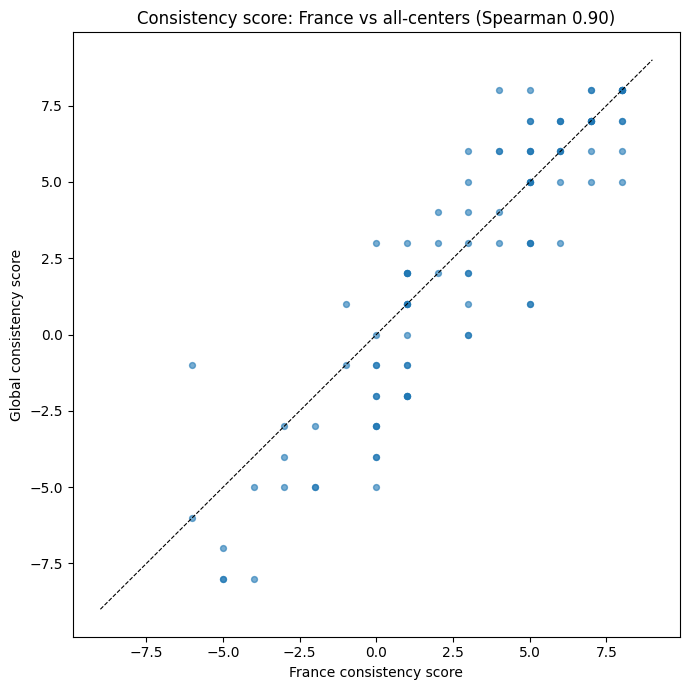

,france_score,global_score
SERUM_ABS_L_glutamic_acid_2,8,8
SERUM_ABS_Sucrose,8,7
SERUM_ABS_maltose_1,8,8
SERUM_ABS_lactose_1,8,8
SERUM_ABS_D_mannose_1,8,7
SERUM_ABS_L_leucine_1,8,8
SERUM_ABS_xylulose,8,8
SERUM_ABS_L_methionine_2,8,6
SERUM_ABS_beta_hydroxyisovalerate,8,5
SERUM_ABS_alpha_ketoglutaric_acid,8,8


In [16]:
# --- 14.5 Global sanity check: are the trends France-specific? -----------------
# Recompute the consistency score on the ALL-CENTERS complete-metabolome cohort
# and compare the per-metabolite ranking against the France result.
_gcomplete = _metab.index[_metab.notna().all(axis=1)]
_ggroups_all = _meta["PATGROUPFINAL_C"].astype(str).reindex(_gcomplete)
_valid = _ggroups_all.notna() & (_ggroups_all != "nan") & _ggroups_all.isin(GROUP_ORDER)
gcohort_ids = _gcomplete[_valid.to_numpy()]
gmetab = _metab.loc[gcohort_ids].astype(float)
ggroups = _meta.loc[gcohort_ids, "PATGROUPFINAL_C"].astype(str)
print(f"Global complete-metabolome cohort n = {len(gcohort_ids)}")


def consistency_score(metab_df, grp):
    """(#groups elevated) - (#groups reduced) per metabolite, FDR<0.05, vs control."""
    cols = {}
    for g in DISEASE:
        d_idx = (grp == g).to_numpy()
        c_idx = (grp == CONTROL).to_numpy()
        if d_idx.sum() == 0 or c_idx.sum() == 0:
            continue
        l2fc, pv = [], []
        for met in metab_df.columns:
            a = metab_df.loc[d_idx, met].to_numpy()
            b = metab_df.loc[c_idx, met].to_numpy()
            _, p = mannwhitneyu(a, b, alternative="two-sided")
            l2fc.append(np.log2(np.median(a) / np.median(b))); pv.append(p)
        fdr = false_discovery_control(np.array(pv))
        cols[g] = pd.Series(np.where(fdr < 0.05, np.sign(l2fc), 0.0),
                            index=metab_df.columns)
    sm = pd.DataFrame(cols)
    return (sm > 0).sum(axis=1) - (sm < 0).sum(axis=1)


global_score = consistency_score(gmetab, ggroups).rename("global_score")
compare = (consistency[["score"]].rename(columns={"score": "france_score"})
           .join(global_score))
corr = compare["france_score"].corr(compare["global_score"], method="spearman")
print(f"Spearman correlation France vs global consistency score: {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(compare["france_score"], compare["global_score"], s=18, alpha=0.6)
lim = [compare.min().min() - 1, compare.max().max() + 1]
ax.plot(lim, lim, ls="--", color="k", lw=0.8)
ax.set_xlabel("France consistency score"); ax.set_ylabel("Global consistency score")
ax.set_title(f"Consistency score: France vs all-centers (Spearman {corr:.2f})")
fig.tight_layout(); plt.show()

compare.sort_values("france_score", ascending=False).head(15)